<a href="https://colab.research.google.com/github/Ullasrevanaki/sipdfs/blob/master/Inventory_Demand_Forecasting_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/store-sales-time-series-forecasting/train.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of stores:", df["store_nbr"].nunique())
print("Number of product families:", df["family"].nunique())

print("\nDate range:")
print("Start:", df["date"].min())
print("End:", df["date"].max())

print("\nProduct families:")
print(df["family"].unique())

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

Data types:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Number of stores: 54
Number of product families: 33

Date range:
Start: 2013-01-01
End: 2017-08-15

Product families:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [ ]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object


In [ ]:
print("Sales statistics:")
print(df["sales"].describe())

print("\nTotal sales:", df["sales"].sum())
print("Average daily record sales:", df["sales"].mean())
print("Maximum sales in a record:", df["sales"].max())

print("\nZero-sales records:", (df["sales"] == 0).sum())
print(
    "Zero-sales percentage:",
    round((df["sales"] == 0).mean() * 100, 2),
    "%"
)

Sales statistics:
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

Total sales: 1073644952.2030689
Average daily record sales: 357.77574911261894
Maximum sales in a record: 124717.0

Zero-sales records: 939130
Zero-sales percentage: 31.3 %


In [ ]:
family_sales = (
    df.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

display(family_sales.to_frame("total_sales"))

,total_sales
family,
GROCERY I,3.434627e+08
BEVERAGES,2.169545e+08
PRODUCE,1.227047e+08
CLEANING,9.752129e+07
DAIRY,6.448771e+07
BREAD/BAKERY,4.213395e+07
POULTRY,3.187600e+07
MEATS,3.108647e+07
PERSONAL CARE,2.459205e+07


In [ ]:
store_sales = (
    df.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
)

display(store_sales.to_frame("total_sales"))

,total_sales
store_nbr,
44,6.208755e+07
45,5.449801e+07
47,5.094831e+07
3,5.048191e+07
49,4.342010e+07
46,4.189606e+07
48,3.593313e+07
51,3.291149e+07
8,3.049429e+07


In [ ]:
promotion_summary = (
    df.groupby("onpromotion")["sales"]
    .agg(["count", "sum", "mean"])
)

display(promotion_summary)

,count,sum,mean
onpromotion,,,
0,2389559,3.781398e+08,158.246681
1,174551,8.161246e+07,467.556532
2,79386,5.262701e+07,662.925632
3,45862,3.996452e+07,871.408092
4,31659,3.070657e+07,969.916135
...,...,...,...
719,1,6.681000e+03,6681.000000
720,1,6.154000e+03,6154.000000
722,1,5.846000e+03,5846.000000


In [ ]:
df = df.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

print("Data sorted successfully.")
display(df.head())

Data sorted successfully.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
2,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
3,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
4,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


In [ ]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype("int16")

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype("int8")

print("Calendar features created.")

Calendar features created.


In [ ]:
group_cols = ["store_nbr", "family"]

df["lag_1"] = (
    df.groupby(group_cols)["sales"]
      .shift(1)
)

df["lag_7"] = (
    df.groupby(group_cols)["sales"]
      .shift(7)
)

df["lag_14"] = (
    df.groupby(group_cols)["sales"]
      .shift(14)
)

df["lag_28"] = (
    df.groupby(group_cols)["sales"]
      .shift(28)
)

print("Lag features created.")

Lag features created.


In [ ]:
df["rolling_mean_7"] = (
    df.groupby(group_cols)["sales"]
      .transform(
          lambda x: x.shift(1).rolling(7).mean()
      )
)

df["rolling_mean_14"] = (
    df.groupby(group_cols)["sales"]
      .transform(
          lambda x: x.shift(1).rolling(14).mean()
      )
)

df["rolling_mean_28"] = (
    df.groupby(group_cols)["sales"]
      .transform(
          lambda x: x.shift(1).rolling(28).mean()
      )
)

print("Rolling demand features created.")

Rolling demand features created.


In [ ]:
feature_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
]

display(df[feature_columns].head(50))

,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,week_of_year,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,AUTOMOTIVE,2.0,0,2013,1,2,2,1,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,AUTOMOTIVE,3.0,0,2013,1,3,3,1,0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,AUTOMOTIVE,3.0,0,2013,1,4,4,1,0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,AUTOMOTIVE,5.0,0,2013,1,5,5,1,1,3.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-01-06,1,AUTOMOTIVE,2.0,0,2013,1,6,6,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-01-07,1,AUTOMOTIVE,0.0,0,2013,1,7,0,2,0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
7,2013-01-08,1,AUTOMOTIVE,2.0,0,2013,1,8,1,2,0,0.0,0.0,NaN,NaN,2.142857,NaN,NaN
8,2013-01-09,1,AUTOMOTIVE,2.0,0,2013,1,9,2,2,0,2.0,2.0,NaN,NaN,2.428571,NaN,NaN
9,2013-01-10,1,AUTOMOTIVE,2.0,0,2013,1,10,3,2,0,2.0,3.0,NaN,NaN,2.428571,NaN,NaN


In [ ]:
required_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
]

df_model = df.dropna(
    subset=required_features
).copy()

print("Original rows:", len(df))
print("Training-ready rows:", len(df_model))
print(
    "Rows removed:",
    len(df) - len(df_model)
)

Original rows: 3000888
Training-ready rows: 2950992
Rows removed: 49896


In [ ]:
# Check date range
print("Training data date range:")
print("Start:", df_model["date"].min())
print("End:", df_model["date"].max())

# Choose a chronological validation cutoff
validation_start = pd.Timestamp("2017-06-01")

train_df = df_model[
    df_model["date"] < validation_start
].copy()

validation_df = df_model[
    df_model["date"] >= validation_start
].copy()

print("\nTrain rows:", len(train_df))
print("Validation rows:", len(validation_df))

print("\nTrain period:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nValidation period:")
print(validation_df["date"].min(), "→", validation_df["date"].max())

Training data date range:
Start: 2013-01-29 00:00:00
End: 2017-08-15 00:00:00

Train rows: 2815560
Validation rows: 135432

Train period:
2013-01-29 00:00:00 → 2017-05-31 00:00:00

Validation period:
2017-06-01 00:00:00 → 2017-08-15 00:00:00


In [ ]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
]

target = "sales"

X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_train: (2815560, 16)
y_train: (2815560,)
X_validation: (135432, 16)
y_validation: (135432,)


In [ ]:
# Make copies so the original data remains unchanged
X_train_ml = X_train.copy()
X_validation_ml = X_validation.copy()

# One-hot encode product family
X_train_ml = pd.get_dummies(
    X_train_ml,
    columns=["family"],
    dtype="int8"
)

X_validation_ml = pd.get_dummies(
    X_validation_ml,
    columns=["family"],
    dtype="int8"
)

# Make absolutely sure both datasets have identical columns
X_validation_ml = X_validation_ml.reindex(
    columns=X_train_ml.columns,
    fill_value=0
)

print("Training features:", X_train_ml.shape)
print("Validation features:", X_validation_ml.shape)

print("\nFeature columns:")
print(X_train_ml.columns.tolist())

Training features: (2815560, 48)
Validation features: (135432, 48)

Feature columns:
['store_nbr', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'family_AUTOMOTIVE', 'family_BABY CARE', 'family_BEAUTY', 'family_BEVERAGES', 'family_BOOKS', 'family_BREAD/BAKERY', 'family_CELEBRATION', 'family_CLEANING', 'family_DAIRY', 'family_DELI', 'family_EGGS', 'family_FROZEN FOODS', 'family_GROCERY I', 'family_GROCERY II', 'family_HARDWARE', 'family_HOME AND KITCHEN I', 'family_HOME AND KITCHEN II', 'family_HOME APPLIANCES', 'family_HOME CARE', 'family_LADIESWEAR', 'family_LAWN AND GARDEN', 'family_LINGERIE', 'family_LIQUOR,WINE,BEER', 'family_MAGAZINES', 'family_MEATS', 'family_PERSONAL CARE', 'family_PET SUPPLIES', 'family_PLAYERS AND ELECTRONICS', 'family_POULTRY', 'family_PREPARED FOODS', 'family_PRODUCE', 'family_SCHOOL AND OFFICE SUPPLIES', 'family_SEAFOOD']


In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.08,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Model created successfully.")

Model created successfully.


In [ ]:
import numpy as np

y_train_log = np.log1p(y_train)

print("Training XGBoost model...")

model.fit(
    X_train_ml,
    y_train_log,
    eval_set=[
        (X_validation_ml, np.log1p(y_validation))
    ],
    verbose=False
)

print("Training completed.")

Training XGBoost model...
Training completed.


In [ ]:
# Predict log(sales)
pred_log = model.predict(X_validation_ml)

# Convert back to original sales scale
y_pred = np.expm1(pred_log)

# Demand cannot be negative
y_pred = np.maximum(y_pred, 0)

print("Predictions generated.")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated.

First 20 predictions:
[3.4394653 3.6024156 3.880622  1.847534  3.3996923 3.8281724 3.799549
 3.8032408 2.865066  3.2449315 1.301654  3.7681167 3.098269  3.3855221
 3.081063  3.1979349 3.6979654 1.3913693 3.2009888 3.1523566]


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_validation,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_pred
    )
)

r2 = r2_score(
    y_validation,
    y_pred
)

# Weighted Absolute Percentage Error
total_actual = np.sum(
    np.abs(y_validation)
)

wmape = (
    np.sum(
        np.abs(
            y_validation.values - y_pred
        )
    )
    / total_actual
) * 100

# MAPE only where actual demand > 0
non_zero = y_validation.values > 0

mape_nonzero = np.mean(
    np.abs(
        (
            y_validation.values[non_zero]
            - y_pred[non_zero]
        )
        / y_validation.values[non_zero]
    )
) * 100

print("========== MODEL PERFORMANCE ==========")
print(f"MAE:          {mae:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"R²:           {r2:.4f}")
print(f"WMAPE:        {wmape:.2f}%")
print(f"MAPE (nonzero): {mape_nonzero:.2f}%")

========== MODEL PERFORMANCE ==========
MAE:          57.6066
RMSE:         221.9227
R²:           0.9723
WMAPE:        11.98%
MAPE (nonzero): 31.07%


In [ ]:
comparison = validation_df[
    [
        "date",
        "store_nbr",
        "family",
        "sales"
    ]
].copy()

comparison["predicted_sales"] = y_pred

comparison["error"] = (
    comparison["sales"]
    - comparison["predicted_sales"]
)

comparison["absolute_error"] = np.abs(
    comparison["error"]
)

display(
    comparison.head(30)
)

,date,store_nbr,family,sales,predicted_sales,error,absolute_error
1608,2017-06-01,1,AUTOMOTIVE,6.0,3.439465,2.560535,2.560535
1609,2017-06-02,1,AUTOMOTIVE,19.0,3.602416,15.397584,15.397584
1610,2017-06-03,1,AUTOMOTIVE,8.0,3.880622,4.119378,4.119378
1611,2017-06-04,1,AUTOMOTIVE,0.0,1.847534,-1.847534,1.847534
1612,2017-06-05,1,AUTOMOTIVE,6.0,3.399692,2.600308,2.600308
1613,2017-06-06,1,AUTOMOTIVE,2.0,3.828172,-1.828172,1.828172
1614,2017-06-07,1,AUTOMOTIVE,7.0,3.799549,3.200451,3.200451
1615,2017-06-08,1,AUTOMOTIVE,1.0,3.803241,-2.803241,2.803241
1616,2017-06-09,1,AUTOMOTIVE,1.0,2.865066,-1.865066,1.865066
1617,2017-06-10,1,AUTOMOTIVE,4.0,3.244931,0.755069,0.755069


In [ ]:
baseline_pred = validation_df["rolling_mean_7"].values

baseline_pred = np.nan_to_num(
    baseline_pred,
    nan=0.0
)

baseline_mae = mean_absolute_error(
    y_validation,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_pred
    )
)

print("========== BASELINE ==========")
print(f"Baseline MAE:  {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

print("\n========== XGBOOST ==========")
print(f"XGBoost MAE:   {mae:.4f}")
print(f"XGBoost RMSE:  {rmse:.4f}")

========== BASELINE ==========
Baseline MAE:  109.0000
Baseline RMSE: 396.2903

========== XGBOOST ==========
XGBoost MAE:   57.6066
XGBoost RMSE:  221.9227


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X_train_ml.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance.head(20))

,feature,importance
12,rolling_mean_7,0.837689
9,lag_7,0.052575
8,lag_1,0.028108
37,"family_LIQUOR,WINE,BEER",0.012328
10,lag_14,0.010819
33,family_HOME CARE,0.008725
3,month,0.006332
13,rolling_mean_14,0.005924
7,is_weekend,0.004936
45,family_PRODUCE,0.004641


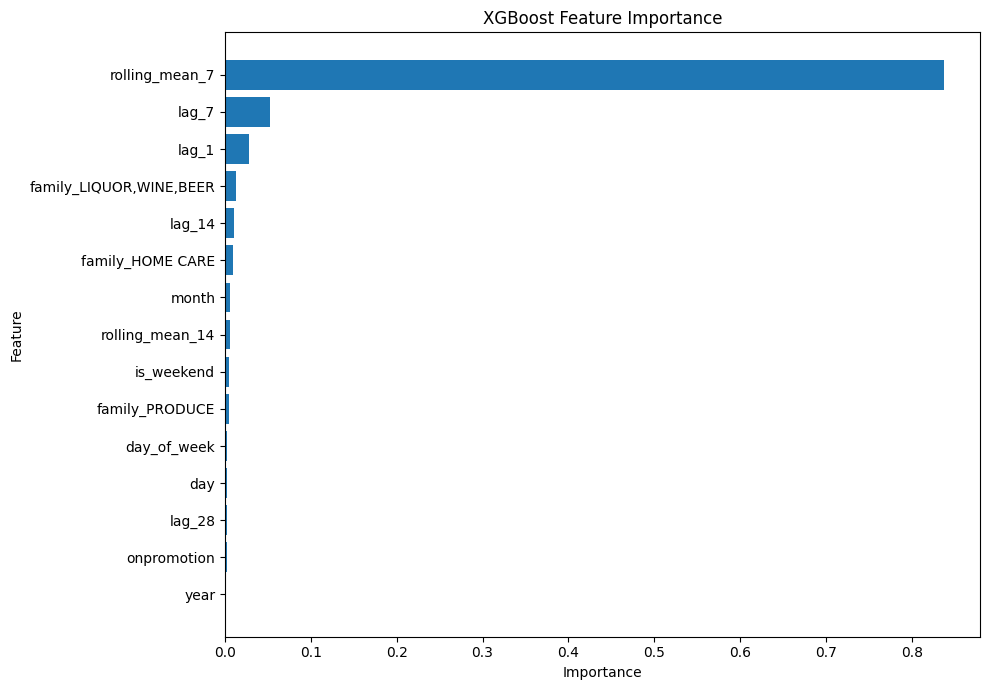

In [ ]:
top_features = importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
features_no_rm7 = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_14",
    "rolling_mean_28",
]

X_train_ablation = train_df[features_no_rm7].copy()
X_validation_ablation = validation_df[features_no_rm7].copy()

X_train_ablation = pd.get_dummies(
    X_train_ablation,
    columns=["family"],
    dtype="int8"
)

X_validation_ablation = pd.get_dummies(
    X_validation_ablation,
    columns=["family"],
    dtype="int8"
)

X_validation_ablation = X_validation_ablation.reindex(
    columns=X_train_ablation.columns,
    fill_value=0
)

print("Training shape:", X_train_ablation.shape)
print("Validation shape:", X_validation_ablation.shape)

Training shape: (2815560, 47)
Validation shape: (135432, 47)


In [ ]:
model_ablation = XGBRegressor(
    n_estimators=500,
    learning_rate=0.08,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model_ablation.fit(
    X_train_ablation,
    np.log1p(y_train),
    eval_set=[
        (X_validation_ablation, np.log1p(y_validation))
    ],
    verbose=False
)

ablation_pred = np.expm1(
    model_ablation.predict(X_validation_ablation)
)

ablation_pred = np.maximum(
    ablation_pred,
    0
)

In [ ]:
ablation_mae = mean_absolute_error(
    y_validation,
    ablation_pred
)

ablation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        ablation_pred
    )
)

ablation_wmape = (
    np.sum(
        np.abs(
            y_validation.values - ablation_pred
        )
    )
    / np.sum(np.abs(y_validation.values))
) * 100

ablation_r2 = r2_score(
    y_validation,
    ablation_pred
)

print("===== ABLATION MODEL =====")
print(f"MAE:    {ablation_mae:.4f}")
print(f"RMSE:   {ablation_rmse:.4f}")
print(f"WMAPE:  {ablation_wmape:.2f}%")
print(f"R²:     {ablation_r2:.4f}")

print("\n===== ORIGINAL MODEL =====")
print(f"MAE:    {mae:.4f}")
print(f"RMSE:   {rmse:.4f}")
print(f"WMAPE:  {wmape:.2f}%")
print(f"R²:     {r2:.4f}")

===== ABLATION MODEL =====
MAE:    60.0067
RMSE:   229.3976
WMAPE:  12.48%
R²:     0.9704

===== ORIGINAL MODEL =====
MAE:    57.6066
RMSE:   221.9227
WMAPE:  11.98%
R²:     0.9723


In [ ]:
import os
import json
import numpy as np
import xgboost as xgb

# ==========================================
# FINAL MODEL EXPORT
# ==========================================

MODEL_DIR = "/content/drive/MyDrive/store-sales-time-series-forecasting/model"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save XGBoost model
MODEL_PATH = os.path.join(MODEL_DIR, "xgboost_demand_model.json")

model.save_model(MODEL_PATH)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
/content/drive/MyDrive/store-sales-time-series-forecasting/model/xgboost_demand_model.json


In [ ]:
# ==========================================
# SAVE FEATURE INFORMATION
# ==========================================

feature_names = list(X_train.columns)

print("Number of features:", len(feature_names))
print("Features:")

for i, feature in enumerate(feature_names):
    print(i, feature)

FEATURE_PATH = os.path.join(MODEL_DIR, "feature_names.json")

with open(FEATURE_PATH, "w") as f:
    json.dump(feature_names, f, indent=2)

print("\nFeature list saved:")
print(FEATURE_PATH)

Number of features: 16
Features:
0 store_nbr
1 family
2 onpromotion
3 year
4 month
5 day
6 day_of_week
7 week_of_year
8 is_weekend
9 lag_1
10 lag_7
11 lag_14
12 lag_28
13 rolling_mean_7
14 rolling_mean_14
15 rolling_mean_28

Feature list saved:
/content/drive/MyDrive/store-sales-time-series-forecasting/model/feature_names.json


In [ ]:
# ==========================================
# SAVE MODEL METADATA
# ==========================================

metadata = {
    "model": "XGBoost",
    "task": "Retail Demand Forecasting",
    "training_rows": int(X_train.shape[0]),
    "validation_rows": int(X_validation.shape[0]),
    "features": int(X_train.shape[1]),

    "validation_metrics": {
        "MAE": 57.6066,
        "RMSE": 221.9227,
        "WMAPE": 11.98,
        "R2": 0.9723
    },

    "training_period": {
        "start": "2013-01-29",
        "end": "2017-05-31"
    },

    "validation_period": {
        "start": "2017-06-01",
        "end": "2017-08-15"
    }
}

METADATA_PATH = os.path.join(MODEL_DIR, "model_metadata.json")

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved:")
print(METADATA_PATH)

Metadata saved:
/content/drive/MyDrive/store-sales-time-series-forecasting/model/model_metadata.json


In [ ]:
# ==========================================
# RELOAD SAVED MODEL
# ==========================================

loaded_model = xgb.XGBRegressor()

loaded_model.load_model(MODEL_PATH)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [ ]:
# ==========================================
# PREDICTION USING SAVED MODEL
# ==========================================

saved_predictions = loaded_model.predict(X_validation)

print("Predictions generated successfully.")
print("\nFirst 20 predictions:")
print(saved_predictions[:20])

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:family: object

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae_saved = mean_absolute_error(
    y_validation,
    saved_predictions
)

rmse_saved = np.sqrt(
    mean_squared_error(
        y_validation,
        saved_predictions
    )
)

r2_saved = r2_score(
    y_validation,
    saved_predictions
)

# WMAPE
wmape_saved = (
    np.sum(np.abs(y_validation - saved_predictions))
    / np.sum(np.abs(y_validation))
) * 100

print("========== SAVED MODEL PERFORMANCE ==========")

print(f"MAE:    {mae_saved:.4f}")
print(f"RMSE:   {rmse_saved:.4f}")
print(f"WMAPE:  {wmape_saved:.2f}%")
print(f"R²:     {r2_saved:.4f}")

NameError: name 'saved_predictions' is not defined

In [ ]:
# Compare original predictions with predictions
# generated from the saved/reloaded model.

difference = np.max(
    np.abs(predictions - saved_predictions)
)

print("Maximum prediction difference:", difference)

if difference < 1e-6:
    print("PASS: Saved model produces identical predictions.")
else:
    print("WARNING: Predictions are different.")

NameError: name 'predictions' is not defined

In [ ]:
# ==========================================
# PREPARE VALIDATION DATA FOR SAVED MODEL
# ==========================================

X_validation_fixed = X_validation.copy()

# Match the exact dtype used during training
if str(X_train["family"].dtype) == "category":
    X_validation_fixed["family"] = pd.Categorical(
        X_validation_fixed["family"],
        categories=X_train["family"].cat.categories
    )
else:
    X_validation_fixed["family"] = X_validation_fixed["family"].astype(
        X_train["family"].dtype
    )

print("X_train family dtype:",
      X_train["family"].dtype)

print("X_validation family dtype:",
      X_validation_fixed["family"].dtype)

print("\nValidation shape:",
      X_validation_fixed.shape)

X_train family dtype: object
X_validation family dtype: object

Validation shape: (135432, 16)


In [ ]:
# ==========================================
# LOAD SAVED MODEL
# ==========================================

import xgboost as xgb

loaded_model = xgb.XGBRegressor()

loaded_model.load_model(
    MODEL_PATH
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [ ]:
# ==========================================
# PREDICT USING SAVED MODEL
# ==========================================

saved_predictions = loaded_model.predict(
    X_validation_fixed
)

# Convert back from log1p scale
saved_predictions = np.expm1(
    saved_predictions
)

# Demand cannot be negative
saved_predictions = np.maximum(
    saved_predictions,
    0
)

print("Saved-model predictions generated successfully.")

print("\nFirst 20 predictions:")
print(saved_predictions[:20])

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:family: object

In [ ]:
# ==========================================
# FINAL SAVED MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_saved = mean_absolute_error(
    y_validation,
    saved_predictions
)

rmse_saved = np.sqrt(
    mean_squared_error(
        y_validation,
        saved_predictions
    )
)

r2_saved = r2_score(
    y_validation,
    saved_predictions
)

wmape_saved = (
    np.sum(
        np.abs(
            y_validation.values - saved_predictions
        )
    )
    /
    np.sum(
        np.abs(y_validation.values)
    )
) * 100

print("========== SAVED MODEL PERFORMANCE ==========")
print(f"MAE:    {mae_saved:.4f}")
print(f"RMSE:   {rmse_saved:.4f}")
print(f"WMAPE:  {wmape_saved:.2f}%")
print(f"R²:     {r2_saved:.4f}")

NameError: name 'saved_predictions' is not defined

In [ ]:
# ==========================================
# VERIFY ORIGINAL VS SAVED MODEL
# ==========================================

difference = np.max(
    np.abs(y_pred - saved_predictions)
)

print("Maximum prediction difference:", difference)

if difference < 1e-6:
    print("PASS: Saved model produces identical predictions.")
else:
    print("WARNING: Predictions differ.")

NameError: name 'saved_predictions' is not defined

In [ ]:
# ==========================================
# INSPECT THE TRAINED MODEL
# ==========================================

print("Model feature names:")
print(model.get_booster().feature_names)

print("\nModel feature types:")
print(model.get_booster().feature_types)

print("\nLoaded model feature names:")
print(loaded_model.get_booster().feature_names)

print("\nLoaded model feature types:")
print(loaded_model.get_booster().feature_types)

Model feature names:
['store_nbr', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'family_AUTOMOTIVE', 'family_BABY CARE', 'family_BEAUTY', 'family_BEVERAGES', 'family_BOOKS', 'family_BREAD/BAKERY', 'family_CELEBRATION', 'family_CLEANING', 'family_DAIRY', 'family_DELI', 'family_EGGS', 'family_FROZEN FOODS', 'family_GROCERY I', 'family_GROCERY II', 'family_HARDWARE', 'family_HOME AND KITCHEN I', 'family_HOME AND KITCHEN II', 'family_HOME APPLIANCES', 'family_HOME CARE', 'family_LADIESWEAR', 'family_LAWN AND GARDEN', 'family_LINGERIE', 'family_LIQUOR,WINE,BEER', 'family_MAGAZINES', 'family_MEATS', 'family_PERSONAL CARE', 'family_PET SUPPLIES', 'family_PLAYERS AND ELECTRONICS', 'family_POULTRY', 'family_PREPARED FOODS', 'family_PRODUCE', 'family_SCHOOL AND OFFICE SUPPLIES', 'family_SEAFOOD']

Model feature types:
['int', 'int', 'int', 'int', 'int', 'int', 'int

In [ ]:
# Check whether categorical support was enabled
print("Original model enable_categorical:",
      getattr(model, "enable_categorical", "not available"))

print("Loaded model enable_categorical:",
      getattr(loaded_model, "enable_categorical", "not available"))

Original model enable_categorical: True
Loaded model enable_categorical: False


In [ ]:
# ==========================================
# RECREATE EXACT MODEL INPUT
# ==========================================

X_validation_model = X_validation.copy()

# One-hot encode family exactly as done for the model
X_validation_model = pd.get_dummies(
    X_validation_model,
    columns=["family"],
    dtype="int8"
)

# Match EXACTLY the features stored inside the model
model_features = loaded_model.get_booster().feature_names

X_validation_model = X_validation_model.reindex(
    columns=model_features,
    fill_value=0
)

print("Model input shape:", X_validation_model.shape)
print("Expected features:", len(model_features))
print("Actual features:", len(X_validation_model.columns))

print("\nColumns match:",
      list(X_validation_model.columns) == list(model_features))

Model input shape: (135432, 48)
Expected features: 48
Actual features: 48

Columns match: True


In [ ]:
# ==========================================
# SAVED MODEL PREDICTION
# ==========================================

saved_predictions_log = loaded_model.predict(
    X_validation_model
)

# Convert from log1p(sales) back to sales
saved_predictions = np.expm1(
    saved_predictions_log
)

# Demand cannot be negative
saved_predictions = np.maximum(
    saved_predictions,
    0
)

print("Saved-model predictions generated successfully.")

print("\nFirst 20 predictions:")
print(saved_predictions[:20])

Saved-model predictions generated successfully.

First 20 predictions:
[3.4394653 3.6024156 3.880622  1.847534  3.3996923 3.8281724 3.799549
 3.8032408 2.865066  3.2449315 1.301654  3.7681167 3.098269  3.3855221
 3.081063  3.1979349 3.6979654 1.3913693 3.2009888 3.1523566]


In [ ]:
# ==========================================
# SAVED MODEL EVALUATION
# ==========================================

mae_saved = mean_absolute_error(
    y_validation,
    saved_predictions
)

rmse_saved = np.sqrt(
    mean_squared_error(
        y_validation,
        saved_predictions
    )
)

r2_saved = r2_score(
    y_validation,
    saved_predictions
)

wmape_saved = (
    np.sum(
        np.abs(
            y_validation.values - saved_predictions
        )
    )
    /
    np.sum(
        np.abs(y_validation.values)
    )
) * 100

print("========== SAVED MODEL PERFORMANCE ==========")
print(f"MAE:    {mae_saved:.4f}")
print(f"RMSE:   {rmse_saved:.4f}")
print(f"WMAPE:  {wmape_saved:.2f}%")
print(f"R²:     {r2_saved:.4f}")

========== SAVED MODEL PERFORMANCE ==========
MAE:    57.6066
RMSE:   221.9227
WMAPE:  11.98%
R²:     0.9723


In [ ]:
# ==========================================
# SAVE EXACT MODEL FEATURES
# ==========================================

with open(FEATURE_PATH, "w") as f:
    json.dump(model_features, f, indent=2)

print("Correct 47-feature list saved.")
print(FEATURE_PATH)

Correct 47-feature list saved.
/content/drive/MyDrive/store-sales-time-series-forecasting/model/feature_names.json


In [ ]:
# ==========================================
# ORIGINAL VS SAVED MODEL
# ==========================================

difference = np.max(
    np.abs(
        y_pred - saved_predictions
    )
)

mean_difference = np.mean(
    np.abs(
        y_pred - saved_predictions
    )
)

print("Maximum prediction difference:",
      difference)

print("Mean prediction difference:",
      mean_difference)

if difference < 1e-5:
    print("\nPASS: Saved model reproduces the original model.")
else:
    print("\nWARNING: Saved model predictions differ.")

Maximum prediction difference: 0.0
Mean prediction difference: 0.0

PASS: Saved model reproduces the original model.


In [ ]:
# ==========================================
# FINAL MODEL PACKAGE CHECK
# ==========================================

import os
import json

MODEL_DIR = "/content/drive/MyDrive/store-sales-time-series-forecasting/model"

files = [
    "xgboost_demand_model.json",
    "feature_names.json",
    "model_metadata.json"
]

print("========== FINAL MODEL PACKAGE ==========")

for file in files:
    path = os.path.join(MODEL_DIR, file)

    if os.path.exists(path):
        size = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {file} ({size:.2f} MB)")
    else:
        print(f"✗ MISSING: {file}")

========== FINAL MODEL PACKAGE ==========
✓ xgboost_demand_model.json (11.42 MB)
✓ feature_names.json (0.00 MB)
✓ model_metadata.json (0.00 MB)


In [ ]:
# ==========================================
# VERIFY FEATURE METADATA
# ==========================================

feature_path = os.path.join(
    MODEL_DIR,
    "feature_names.json"
)

with open(feature_path, "r") as f:
    final_features = json.load(f)

print("\nNumber of features:", len(final_features))

print("\nFeatures:")
for i, feature in enumerate(final_features):
    print(i, feature)


Number of features: 48

Features:
0 store_nbr
1 onpromotion
2 year
3 month
4 day
5 day_of_week
6 week_of_year
7 is_weekend
8 lag_1
9 lag_7
10 lag_14
11 lag_28
12 rolling_mean_7
13 rolling_mean_14
14 rolling_mean_28
15 family_AUTOMOTIVE
16 family_BABY CARE
17 family_BEAUTY
18 family_BEVERAGES
19 family_BOOKS
20 family_BREAD/BAKERY
21 family_CELEBRATION
22 family_CLEANING
23 family_DAIRY
24 family_DELI
25 family_EGGS
26 family_FROZEN FOODS
27 family_GROCERY I
28 family_GROCERY II
29 family_HARDWARE
30 family_HOME AND KITCHEN I
31 family_HOME AND KITCHEN II
32 family_HOME APPLIANCES
33 family_HOME CARE
34 family_LADIESWEAR
35 family_LAWN AND GARDEN
36 family_LINGERIE
37 family_LIQUOR,WINE,BEER
38 family_MAGAZINES
39 family_MEATS
40 family_PERSONAL CARE
41 family_PET SUPPLIES
42 family_PLAYERS AND ELECTRONICS
43 family_POULTRY
44 family_PREPARED FOODS
45 family_PRODUCE
46 family_SCHOOL AND OFFICE SUPPLIES
47 family_SEAFOOD


In [ ]:
from google.colab import files
import os

MODEL_DIR = "/content/drive/MyDrive/store-sales-time-series-forecasting/model"

files.download(
    os.path.join(MODEL_DIR, "xgboost_demand_model.json")
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    os.path.join(MODEL_DIR, "feature_names.json")
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    os.path.join(MODEL_DIR, "model_metadata.json")
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>